In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#| label: load-data
df1 = pd.read_csv("anonymized_all.csv")
df2 = pd.read_csv("anonymized_fy24_only.csv")

In [3]:
#| label: data-clean-fn
def clean_df(df, date_col, drop_col):
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.drop([drop_col], axis = 1)
    df.columns = df.columns.str.lower()
    
    return df

cleaned_df1 = clean_df(df1,'Start Date', 'Client Name')
cleaned_df2 = clean_df(df2,'Start Date', 'Client Name')

In [4]:
cleaned_df1.head()

,unique identifier,start date,job id
0,537926,2021-06-14,job-188418
1,476870,2021-06-18,job-188751
2,458255,2021-06-14,job-189026
3,479256,2020-08-04,job-181914
4,472697,2020-08-07,job-181916


In [5]:
#| label: fiscal-year-function
def fiscal_year(date):
    if date.month >=7:
        return date.year + 1
    else:
        return date.year
    
cleaned_df1['fiscal year'] = cleaned_df1['start date'].apply(fiscal_year)
cleaned_df2['fiscal year'] = cleaned_df2['start date'].apply(fiscal_year)

In [6]:
#| label: check-years-in-dataset-1
cleaned_df1['fiscal year'].unique()

array([2021, 2022, 2023, 2024])

In [7]:
#| label: check-years-in-dataset-2
cleaned_df2['fiscal year'].unique()

array([2024])

In [8]:
# <!-- ```{python}
# merged_df = pd.merge(cleaned_all, cleaned_fy24, how = 'outer')
# merged_df
# ```



# ```{python}
# merged_df['fiscal year'] = merged_df['start date'].apply(get_fiscal_year)
# merged_df.head()
# ```
# ```{python}
# merged_df['fiscal year'].unique()
# ```

# ```{python}
# merged_df = merged_df[merged_df['fiscal year'].isin([2023, 2024])]
# merged_df
# ```

# ```{python}
# weekly_performance = (
#   merged_df
#   .groupby(['fiscal year', pd.Grouper(key='start date', freq='W')]).size()
#   .reset_index(name = 'weekly_performance')
# )

# weekly_performance
# ```

# ```{python}
# weekly_performance['cumulative_performance'] = (
#   weekly_performance
#   .groupby('fiscal year')['weekly_performance']
#   .cumsum()
# )

# weekly_performance
# ```
# ```{python}
# # Pivot the data
# weekly_performance['start date'] = weekly_performance['start date'].dt.strftime('%m-%d')

# pivoted_data = weekly_performance.pivot(index='start date', columns='fiscal year', values='cumulative_performance')
# pivoted_data.columns = [f'Cumulative Performance FY{year}' for year in pivoted_data.columns]

# pivoted_data.reset_index(inplace=True)

# pivoted_data
# ```
# ```{python}
# # Plotting
# fig, ax = plt.subplots(figsize=(10, 6))
# pivoted_data.plot(x='start date', ax=ax)

# ax.set_title('Cumulative Weekly Performance by Fiscal Year')
# ax.set_xlabel('Date')
# ax.set_ylabel('Cumulative Performance')
# ax.legend()

# plt.show()
# ```
# ```{python}
# weekly_performance.to_csv("weekly_performance.csv", index = False) 
# ``` -->


In [9]:
#| label: filter-fy24-previous
cleaned_previous = cleaned_df1[cleaned_df1['fiscal year'].isin([2024])]
cleaned_previous

,unique identifier,start date,job id,fiscal year
8381,581013,2023-09-25,job-193451,2024
8382,583586,2023-07-17,job-198299,2024
8383,585047,2023-07-11,job-198331,2024
8384,576444,2023-07-09,job-198365,2024
8385,585401,2023-09-18,job-198436,2024
...,...,...,...,...
11009,619903,2024-03-13,job-205994,2024
11010,602062,2024-03-26,job-206010,2024
11011,598480,2024-03-06,job-206013,2024
11012,615498,2024-03-03,job-206017,2024


In [10]:
#| label: calc-previous-weekly-performance
previous_weekly_performance = (
  cleaned_previous
  .groupby(['fiscal year', pd.Grouper(key='start date', freq='W')]).size()
  .reset_index(name = 'previous_weekly_performance')
)
previous_weekly_performance

,fiscal year,start date,previous_weekly_performance
0,2024,2023-07-02,15
1,2024,2023-07-09,77
2,2024,2023-07-16,99
3,2024,2023-07-23,71
4,2024,2023-07-30,72
5,2024,2023-08-06,97
6,2024,2023-08-13,91
7,2024,2023-08-20,100
8,2024,2023-08-27,92
9,2024,2023-09-03,96


In [11]:
#| label: calc-previous-week-over-week-performance
previous_weekly_performance['cumulative_performance'] = (
  previous_weekly_performance
  .groupby('fiscal year')['previous_weekly_performance']
  .cumsum()
)

In [12]:
previous_weekly_performance

,fiscal year,start date,previous_weekly_performance,cumulative_performance
0,2024,2023-07-02,15,15
1,2024,2023-07-09,77,92
2,2024,2023-07-16,99,191
3,2024,2023-07-23,71,262
4,2024,2023-07-30,72,334
5,2024,2023-08-06,97,431
6,2024,2023-08-13,91,522
7,2024,2023-08-20,100,622
8,2024,2023-08-27,92,714
9,2024,2023-09-03,96,810


In [13]:
current_weekly_performance = (
  cleaned_df2
  .groupby(['fiscal year', pd.Grouper(key='start date', freq='W')]).size()
  .reset_index(name = 'current_weekly_performance')
)
current_weekly_performance

,fiscal year,start date,current_weekly_performance
0,2024,2023-07-02,15
1,2024,2023-07-09,77
2,2024,2023-07-16,98
3,2024,2023-07-23,72
4,2024,2023-07-30,72
5,2024,2023-08-06,100
6,2024,2023-08-13,93
7,2024,2023-08-20,101
8,2024,2023-08-27,92
9,2024,2023-09-03,96


In [14]:
current_weekly_performance['current_cumulative_performance']= (
  current_weekly_performance
  .groupby('fiscal year')['current_weekly_performance']
  .cumsum()
)
current_weekly_performance

,fiscal year,start date,current_weekly_performance,current_cumulative_performance
0,2024,2023-07-02,15,15
1,2024,2023-07-09,77,92
2,2024,2023-07-16,98,190
3,2024,2023-07-23,72,262
4,2024,2023-07-30,72,334
5,2024,2023-08-06,100,434
6,2024,2023-08-13,93,527
7,2024,2023-08-20,101,628
8,2024,2023-08-27,92,720
9,2024,2023-09-03,96,816


In [15]:
#| label: merge-dfs
merged_df = pd.merge(previous_weekly_performance, current_weekly_performance, how = 'outer')
merged_df

,fiscal year,start date,previous_weekly_performance,cumulative_performance,current_weekly_performance,current_cumulative_performance
0,2024,2023-07-02,15,15,15,15
1,2024,2023-07-09,77,92,77,92
2,2024,2023-07-16,99,191,98,190
3,2024,2023-07-23,71,262,72,262
4,2024,2023-07-30,72,334,72,334
5,2024,2023-08-06,97,431,100,434
6,2024,2023-08-13,91,522,93,527
7,2024,2023-08-20,100,622,101,628
8,2024,2023-08-27,92,714,92,720
9,2024,2023-09-03,96,810,96,816


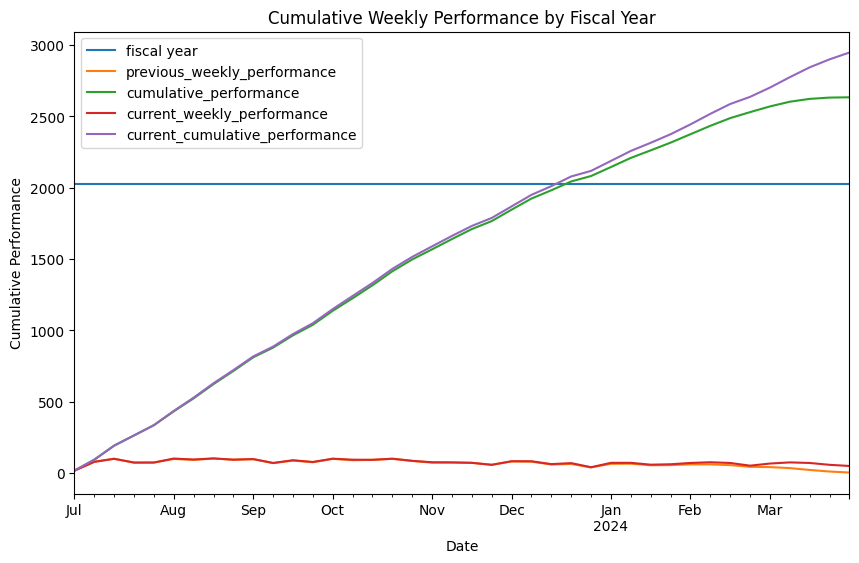

In [16]:
#| label: fig-line-chart
#| fig-cap: "Marginal distributions of bill dimensions"
#| fig-subcap: 
#|   - "Gentoo penguins tend to have thinner bills,"
#|   - "and Adelie penguins tend to have shorter bills."
#| fig-alt:
#|   - "Density plot of bill depth by species."
#|   - "Density plot of bill length by species."
#| layout-ncol: 1


fig, ax = plt.subplots(figsize=(10, 6))
merged_df.plot(x='start date', ax=ax)

ax.set_title('Cumulative Weekly Performance by Fiscal Year')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Performance')
ax.legend()

plt.show()

In [ ]:
{{< embed 1-intervention-analysis.ipynb#fig-line-chart >}}